# Data Cleaning

In [21]:
# Import Library
import numpy as np
import pandas as pd
import re as re

import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

In [22]:
# Display all columns and all outputs (for observation purposes)
pd.set_option('display.max_columns', None)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [23]:
# Read file
df = pd.read_csv("dtype_cleaned.csv", low_memory=False)

In [24]:
# Delete unnecessary columns
# Train set
df = df.drop("ID", axis=1)
df = df.drop("Name", axis=1)
df = df.drop("SSN", axis=1)

### Tách bộ data train và test

In [25]:
# Split train and test sets
# Pick randomly 80/20 customer_id from the dataset
unique_customers = df['Customer_ID'].unique()
cust_labels = df.groupby('Customer_ID')['Credit_Score'].first()

train_cust, test_cust = train_test_split(unique_customers, test_size=0.2, random_state=4, stratify=cust_labels.loc[unique_customers])

train_df = df[df["Customer_ID"].isin(train_cust)]
test_df = df[df["Customer_ID"].isin(test_cust)]

# Clean Columns

In [26]:
# Categorize dataset into 2 groups of datatypes

object_columns = train_df.select_dtypes(include=['object']).columns.tolist()
numeric_columns = train_df.select_dtypes(include=np.number).columns.tolist()

object_columns
numeric_columns

['Customer_ID',
 'Month',
 'Occupation',
 'Type_of_Loan',
 'Credit_Mix',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Payment_Behaviour',
 'Credit_Score']

['Age',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance']

In [27]:
train_df.iloc[:8] # 3 unnecessary columns have been dropped

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
8,CUS_0x21b1,January,28,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4.0,5.42,2.0,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825,Low_spent_Small_value_payments,470.690627,Standard
9,CUS_0x21b1,February,28,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,1.0,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.391238,High_spent_Large_value_payments,484.591214,Good
10,CUS_0x21b1,March,28,Teacher,34847.84,3037.986667,2,1385,6,1,Credit-Builder Loan,3,-1.0,5.42,2.0,_,605.03,33.224951,26 Years and 9 Months,No,18.816215,58.515976,High_spent_Large_value_payments,466.466476,Standard
11,CUS_0x21b1,April,28,Teacher,34847.84,NaN,2,4,6,1,Credit-Builder Loan,3,3.0,5.42,2.0,Good,605.03,39.182656,26 Years and 10 Months,No,18.816215,99.306228,Low_spent_Medium_value_payments,465.676224,Good
12,CUS_0x21b1,May,28,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1.0,6.42,2.0,Good,605.03,34.977895,26 Years and 11 Months,No,18.816215,130.115420,Low_spent_Small_value_payments,444.867032,Good
13,CUS_0x21b1,June,28,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,0.0,5.42,2.0,Good,605.03,33.381010,27 Years and 0 Months,No,18.816215,43.477190,High_spent_Large_value_payments,481.505262,Good
14,CUS_0x21b1,July,28,Teacher,34847.84,NaN,2,4,6,1,Credit-Builder Loan,3,4.0,5.42,2.0,Good,605.03,31.131702,27 Years and 1 Months,NM,18.816215,70.101774,High_spent_Medium_value_payments,464.880678,Good
15,CUS_0x21b1,August,28,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4.0,5.42,2.0,Good,605.03,32.933856,27 Years and 2 Months,No,18.816215,218.904344,Low_spent_Small_value_payments,356.078109,Good


In [28]:
# Special columns to clean seperately
skip_columns = ["Customer_ID", "Credit_History_Age"]

In [29]:
# Cleaned columns
cleaned_num_cols = ["Credit_Utilization_Ratio"]
cleaned_cat_cols = ["Credit_Score", "Payment_of_Min_Amount", "Month"]

- Realize there are discrete and continuous num cols
- Clean them in 2 different function
- Seperate them into 2 groups
- Some are't even have outlier but have negative values
- Some discrete features have missing values
- Cleaning process: clean by Customer_ID but if Customer_ID has too many missing values -> Group by Credit_score
- Monthly_Inhand_Salary has missing values but doesn't have outliers -> apply different cleaning process

In [30]:
train_df["Credit_Utilization_Ratio"].isnull().sum()

np.int64(0)

### Numerical Features

In [31]:
# 2 features are being used for cleaning
customer_col = "Customer_ID"
score_col = "Credit_Score"

In [32]:
# List of columns that needed to be cleaned
uncleaned_num_cols = list(set(numeric_columns) - set(cleaned_num_cols))

Quy trình xử lý các cột nhóm numerical:
- Xử lý và xóa các value âm -> xử lý và xóa các outlier -> các value bị xóa và missing values sau đó được fill theo nhóm nhỏ
- Value âm: Tìm các value âm -> thành missing values
- Outlier: sử dụng IQR (tứ phân vị) để tìm ra outlier các cột rồi xóa. IQR khi xử lý bộ train sẽ lưu lại range/ bound từng cột thành 1 list rồi được xử lý khi xử lý bộ test (đồng bộ khi clean)
- Tách phần xử lý missing values của các cột dạng discrete và continuous riêng ra
- Cột discrete tính mode theo các nhóm khách hàng, với các missing values còn lại thì tính mode theo nhóm credit_score
- Cột continuous tương tự nhưng được tính bằng median

#### Cleaning negatives

In [33]:
# A function to fill to replace negative values with nan
def clean_negatives(df, col):
    # Replace negatives with NaN
    df.loc[df[col] < 0, col] = np.nan

    return df

In [34]:
# Clean the negative first
negative_cols = [
    "Age",
    "Num_Bank_Accounts",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit"]

# Clean the negative first
for col in negative_cols:
    train_df.loc[:, col] = clean_negatives(train_df, col) # Cleaning train set
    test_df.loc[:, col] = clean_negatives(test_df, col) # Cleaning test set

#### Cleaning outliers

In [35]:
# A function to find outliers of numerical features
def find_num_outlier_by_customers(df, col):
    # Detect continous outlier using IQR
    # Multivariate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound

In [36]:
# A function to clean outliers of numerical features
def clean_num_outliers(df, col, bounds=None):

    df = df.copy() # safe copy

    if bounds is not None:
        lower, upper = bounds
    else:
        lower,upper = find_num_outlier_by_customers(df, col)

    # Detect outliers using the provided function
    outlier_mask = (df[col] < lower) | (df[col] > upper)

    # Replace outliers with NaN
    df.loc[outlier_mask, col] = np.nan

    return df[col]

In [37]:
# Clean numerical outliers
num_bounds = {} # A dict to store thresholds for each feature

# Clean training set
for col in uncleaned_num_cols:
    print(f"Col: ", col)
    lower, upper = find_num_outlier_by_customers(train_df, col)
    num_bounds[col] = (lower, upper)
    train_df.loc[:, col] = clean_num_outliers(train_df, col, num_bounds[col]) # Cleaning train set

# Clean testing set
for col in uncleaned_num_cols:
    print(f"Col: ", col)
    bounds = num_bounds[col] # Use available ranges to clean test set similarly
    test_df.loc[:, col] = clean_num_outliers(test_df, col, bounds) # Cleaning test set

Col:  Monthly_Balance
Col:  Monthly_Inhand_Salary
Col:  Num_of_Loan
Col:  Delay_from_due_date
Col:  Amount_invested_monthly
Col:  Num_Bank_Accounts
Col:  Interest_Rate
Col:  Total_EMI_per_month
Col:  Num_Credit_Inquiries
Col:  Num_Credit_Card
Col:  Age


C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\3237771876.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6.  6.  6. ... nan  7.  7.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, col] = clean_num_outliers(train_df, col, num_bounds[col]) # Cleaning train set
C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\3237771876.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 4.  4. nan ...  6.  6.  6.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, col] = clean_num_outliers(train_df, col, num_bounds[col]) # Cleaning train set
C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\3237771876.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3. 3. 3. ... 5. 

Col:  Annual_Income
Col:  Changed_Credit_Limit
Col:  Num_of_Delayed_Payment
Col:  Outstanding_Debt
Col:  Monthly_Balance
Col:  Monthly_Inhand_Salary
Col:  Num_of_Loan
Col:  Delay_from_due_date
Col:  Amount_invested_monthly
Col:  Num_Bank_Accounts
Col:  Interest_Rate
Col:  Total_EMI_per_month
Col:  Num_Credit_Inquiries
Col:  Num_Credit_Card
Col:  Age
Col:  Annual_Income
Col:  Changed_Credit_Limit
Col:  Num_of_Delayed_Payment
Col:  Outstanding_Debt


C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\3237771876.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4. 4. 4. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[:, col] = clean_num_outliers(test_df, col, bounds) # Cleaning test set


#### Filling missing values

In [38]:
# Differentiate intteger features vs float
int_cols = ["Age", "Num_Bank_Accounts", "Num_of_Delayed_Payment", "Num_of_Loan", "Num_Credit_Card","Delay_from_due_date", "Num_Credit_Inquiries"]
float_cols = list(set(uncleaned_num_cols) - set(int_cols))
int_cols
float_cols

['Age',
 'Num_Bank_Accounts',
 'Num_of_Delayed_Payment',
 'Num_of_Loan',
 'Num_Credit_Card',
 'Delay_from_due_date',
 'Num_Credit_Inquiries']

['Monthly_Balance',
 'Monthly_Inhand_Salary',
 'Annual_Income',
 'Changed_Credit_Limit',
 'Amount_invested_monthly',
 'Outstanding_Debt',
 'Interest_Rate',
 'Total_EMI_per_month']

In [39]:
def fill_nan(df, col, customer_col, group_col, int_cols):
    df = df.copy() # safe copy
    # Fill by customer_id
    customer_fill  = df.groupby(customer_col)[col].transform(lambda x: x.fillna(x.mean()))
    df.loc[df[col].isna(), col] = customer_fill[df[col].isna()]

    # Only fill remaining NaNs by credit_score group
    group_fill  = df.groupby(group_col)[col].transform(lambda x: x.median())
    df.loc[df[col].isna(), col] = group_fill[df[col].isna()]

    if col in int_cols:
        df[col] = df[col].round()
        df[col] = df[col].astype(int)

    return df[col]

In [40]:
# Fill numerical outliers

# Fill training set
print("--Training Set--")
for col in uncleaned_num_cols:
    print(f"Current Column: ", col)
    train_df.loc[:, col] = fill_nan(train_df, col, customer_col, score_col, int_cols)

# Fill test set
print("--Testing Set--")
for col in uncleaned_num_cols:
    print(f"Current Column: ", col)
    test_df.loc[:, col] = fill_nan(test_df, col, customer_col, score_col, int_cols)

--Training Set--
Current Column:  Monthly_Balance
Current Column:  Monthly_Inhand_Salary
Current Column:  Num_of_Loan
Current Column:  Delay_from_due_date
Current Column:  Amount_invested_monthly
Current Column:  Num_Bank_Accounts
Current Column:  Interest_Rate
Current Column:  Total_EMI_per_month
Current Column:  Num_Credit_Inquiries
Current Column:  Num_Credit_Card
Current Column:  Age
Current Column:  Annual_Income
Current Column:  Changed_Credit_Limit
Current Column:  Num_of_Delayed_Payment
Current Column:  Outstanding_Debt
--Testing Set--
Current Column:  Monthly_Balance
Current Column:  Monthly_Inhand_Salary
Current Column:  Num_of_Loan
Current Column:  Delay_from_due_date
Current Column:  Amount_invested_monthly
Current Column:  Num_Bank_Accounts
Current Column:  Interest_Rate
Current Column:  Total_EMI_per_month
Current Column:  Num_Credit_Inquiries
Current Column:  Num_Credit_Card
Current Column:  Age
Current Column:  Annual_Income
Current Column:  Changed_Credit_Limit
Current

In [41]:
# Check for the remaining missing values & data types
train_df[numeric_columns].isnull().sum()
train_df[numeric_columns].dtypes

test_df[numeric_columns].isnull().sum()
test_df[numeric_columns].dtypes

Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Amount_invested_monthly     0
Monthly_Balance             0
dtype: int64

Age                         float64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object

Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Amount_invested_monthly     0
Monthly_Balance             0
dtype: int64

Age                         float64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object

### Categorical Features


In [42]:
uncleaned_cat_cols = list(set(object_columns) - set(cleaned_cat_cols) - set(skip_columns))

In [43]:
# Missing values of categorical columns
train_df[uncleaned_cat_cols].isnull().sum()

Occupation              0
Credit_Mix              0
Type_of_Loan         9064
Payment_Behaviour       0
dtype: int64

In [44]:
# Put Type_of_Loan aside
uncleaned_cat_cols = list(set(uncleaned_cat_cols) - {"Type_of_Loan"})
uncleaned_cat_cols

['Occupation', 'Credit_Mix', 'Payment_Behaviour']

Quy trình xử lý các cột nhóm categorical:
- Sau khi quan sát thì thấy outlier chủ yếu của nhóm này là các ký tự đặc biệt và missing values
- Riêng trường hợp của Type_of_Loan và Credit_History_Age đặc biệt hơn nên sẽ được xử lý riêng
- Tạo một function để tìm các outlier của từng cột (tìm các value có ký tự đặc biệt)
- Các outlier sẽ được xóa -> được thế vào bằng của mode của từng nhóm khách hàng và credit_score
- Áp dụng tương tự cho bộ set

In [45]:
# A function to find outliers with character rules
def find_cat_outliers(val):
    if pd.isna(val):
        return False
    val = str(val)
    return not re.search(r'[a-zA-Z]', val)

In [46]:
# A function to clean outliers of categorical features
def clean_cat_outlier(df, col, customer_col, group_col):
    # Find outliers then replace them with nan
    df.loc[df[col].apply(find_cat_outliers), col] = np.nan

    # For categorical we use mode
    # Fill by customer_id
    filled = df.groupby(customer_col)[col].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))

    # Only fill remaining NaNs by credit_score group
    group_modes = df.groupby(group_col)[col].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )

    filled = filled.where(~filled.isna(), group_modes)

    return filled

In [47]:
# Clean categorical outliers
for col in uncleaned_cat_cols:
    train_df.loc[:, col] = clean_cat_outlier(train_df, col, customer_col, score_col)
    test_df.loc[:, col] = clean_cat_outlier(test_df, col, customer_col, score_col)

#### Type_of_Loan

Quy trình xử lý cột Type_of_Loan:
- Vấn đề chính của cột này là missing values
- Tách string ra thành lists cho từng rows
- Sử dụng encode
- Fill những missing values còn lại
- Tương tự với các nhóm category còn lại, sử dụng mode để xử lý các missing values
(Với trường hợp của bộ test thì xây một function encode khác)

In [48]:
df["Type_of_Loan"].unique()

array(['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
       'Credit-Builder Loan', 'Auto Loan, Auto Loan, and Not Specified',
       ..., 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan',
       'Payday Loan, Student Loan, Mortgage Loan, and Not Specified',
       'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan'],
      dtype=object)

In [49]:
# Clean and split values in rows into lists
def clean_type_of_loan(value):

    if pd.isna(value):
        return [] # empty list for missing

    # Convert to string  and strip leading/trailing spaces
    value = str(value).strip()
    if not value: return [] # After stripping and still nan -> nan

    parts = re.split(r",|\band\b", value, flags=re.IGNORECASE) # split on comma or 'and'

    # Remove whitespace and keep non-empty parts
    parts = [p.strip() for p in parts if p.strip()]
    return sorted(set(parts)) # Lists of loans for each row

In [50]:
# A function for encoding using MultiLabelBinarizer
def encode_loans(df, col):
    # Clean
    df = df.copy()
    df.loc[:, col] = df[col].apply(clean_type_of_loan)

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(df[col])

    # Merge encoded columns back to df
    df[col] = [row for row in encoded]

    return df, mlb

In [51]:
# A function for filling missing values
def fill_nan_loan(df, col, customer_col, group_col):
    df = df.copy()

    def is_missing(v):
        return not isinstance(v, np.ndarray) or v.size == 0 or np.all(v == 0)

    # A helprer function for both cases
    def fill_group(vectors):

        # Keep non-missing vectors
        valid = [np.array(v) for v in vectors if isinstance(v, (list, np.ndarray))]

        # No valid vectors -> skip to using credit score
        if not valid:
          return vectors
        # Compute mean of all non-missing vectors
        mean_vec = np.nanmean(valid, axis=0)

        # Replace nan rows with mean vector
        filled = []
        for v in vectors:
          if isinstance(v, float) and np.isnan(v): # if this row is nan
            filled.append(mean_vec.tolist())
          else:
            filled.append(v)

        return filled

    # Fill missing values with mode of each customer
    df = df.groupby(customer_col, group_keys=False).apply(fill_group)

    # Fill missing values with mode of each credit_score group
    df = df.groupby(group_col, group_keys=False).apply(fill_group)

    return df

In [52]:
# A specific function for test set
# encode_loan will refit the encoder every time
# -> the test set will not having the same columns as test set
def encode_loans_test(df, col, mlb):

    df = df.copy()
    df[col] = df[col].apply(clean_type_of_loan)

    encoded = mlb.transform(df[col])

    df[col] = [row for row in encoded]
    return df


In [53]:
# A function process all the functions above that can be used for each set
def process_loan(df, col, customer_col, group_col, mlb=None):
    # Encode
    if mlb is None:
        df, mlb = encode_loans(df, col)
    else:
        df = encode_loans_test(df, col, mlb)

    # Fill missing values
    df = fill_nan_loan(df, col, customer_col, group_col)

    return df, mlb

In [54]:
train_df, mlb = process_loan(train_df, "Type_of_Loan", customer_col, score_col)
test_df, _ = process_loan(test_df, "Type_of_Loan", customer_col, score_col, mlb)

C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\925369605.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(customer_col, group_keys=False).apply(fill_group)
C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\925369605.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(group_col, group_keys=False).apply(fill_group)
C:\Users\daoth\AppData\Local\Temp\ipykernel_5664\92536960

In [55]:
# Check for remaining missing values
train_df["Type_of_Loan"].isnull().sum()
test_df["Type_of_Loan"].isnull().sum()

np.int64(0)

np.int64(0)

#### Credit_History_Age

Quy trình xử lý cột Credit_History_Age:
- Vấn đề chính của cột này là missing values
- Trước khi xử lý các missing values, convert dạng string sang dạng int
- Xử lý các missing value bằng cách dựa thứ tự các row trong nhóm khách hàng, row trước và row sau
- Trong trường hợp nhóm khách hàng chỉ có mỗi missing values thì lấy mean của nhóm credit_score

In [56]:
# Covert texts to numerical values
def text_to_months(s):
    if not isinstance(s, str): return np.nan
    s_cleaned = s.strip().lower()

    # Captures "<X> years abd <Y> months"
    pattern = r"(\d+)\s+years?\s+and\s+(\d+)\s+months?"
    match = re.search(pattern, s_cleaned) # return month and year values
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return (years * 12) + months
    else: return np.nan

In [57]:
# Fill in the missing values
def fill_from_neighbors(s):

    s_filled = s.copy()

    # Find indices where values are nan
    nan_indices = s_filled[s_filled.isnull()].index

    # Loop through missing values
    for i in nan_indices:
        loc = s_filled.index.get_loc(i)

        # Look back to the previous row
        if loc > 0:
            prev_val = s_filled.iloc[loc - 1]
            if pd.notna(prev_val): # Based on the previous value to fill in nan
                s_filled.loc[i] = prev_val + 1
                continue

        # Look foward to the next row
        if loc < len(s_filled) - 1:
            next_val = s_filled.iloc[loc + 1]
            if pd.notna(next_val): # Based on the next value to fill in nan
                s_filled.loc[i] = next_val - 1
                continue

    return s_filled


In [58]:
def convert_months(df, col, customer_column, score_column):
    # Convert texts to numerical month values
    df.loc[:, col] = df[col].apply(text_to_months)

    # Before filling, sort to make the neighbor logic works
    df = df.sort_values(by=[customer_column, "Month"])

    # Fill missing values per customer using with neighbor logic
    df.loc[:, col] = df.groupby(customer_column)[col].transform(fill_from_neighbors)

    # There are few cases of missing values for the whole 8 rows
    # Fill the remaining nan with mean of the credit_score groups
    group_mean = df.groupby(score_column)[col].transform(
        lambda x: x.astype(float).fillna(x.mean())
    )
    df.loc[:, col] = df[col].astype(float).fillna(group_mean) # Adding astype to avoid warnings

    # Convert to interger
    df.loc[:, col] = df[col].round().astype(int)

    return df


In [59]:
col_to_clean = 'Credit_History_Age' # Clean Credit_History_Age
train_df = convert_months(train_df, col_to_clean, customer_col, score_col)
test_df = convert_months(test_df, col_to_clean, customer_col, score_col)

#### Credit_Score

In [60]:
# Credit_Score
train_df.loc[:, "Credit_Score"] = train_df["Credit_Score"].replace("Standard", "Good")
test_df.loc[:, "Credit_Score"] = test_df["Credit_Score"].replace("Standard", "Good")

In [61]:
# # Checking
# score_map = {"Poor" : 2, "Standard" : 1, "Good" : 0} # Nhom pos de 0
# train_df["Credit_Score"] = train_df["Credit_Score"].map(score_map)
# test_df["Credit_Score"] = test_df["Credit_Score"].map(score_map)

# # Credit_Mix
# mix_nap = {"Bad": 2, "Standard": 1, "Good": 0 }
# train_df["Credit_Mix"] = train_df["Credit_Mix"].map(mix_nap)
# test_df["Credit_Mix"] = test_df["Credit_Mix"].map(mix_nap)

# # Correlation Matrix
# import seaborn as sns
# corr_matrix = train_df.corr(numeric_only=True)
# plt.figure(figsize=(20,10))
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
# plt.show()

# Export files


In [62]:
train_df.to_csv("train_cleaned.csv", index=False)
test_df.to_csv("test_cleaned.csv", index=False)

In [63]:
np.isfinite(train_df[numeric_columns]).all(axis=0)

Age                         True
Annual_Income               True
Monthly_Inhand_Salary       True
Num_Bank_Accounts           True
Num_Credit_Card             True
Interest_Rate               True
Num_of_Loan                 True
Delay_from_due_date         True
Num_of_Delayed_Payment      True
Changed_Credit_Limit        True
Num_Credit_Inquiries        True
Outstanding_Debt            True
Credit_Utilization_Ratio    True
Total_EMI_per_month         True
Amount_invested_monthly     True
Monthly_Balance             True
dtype: bool

# Graphing - After Cleaning

<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Missing Data Map')

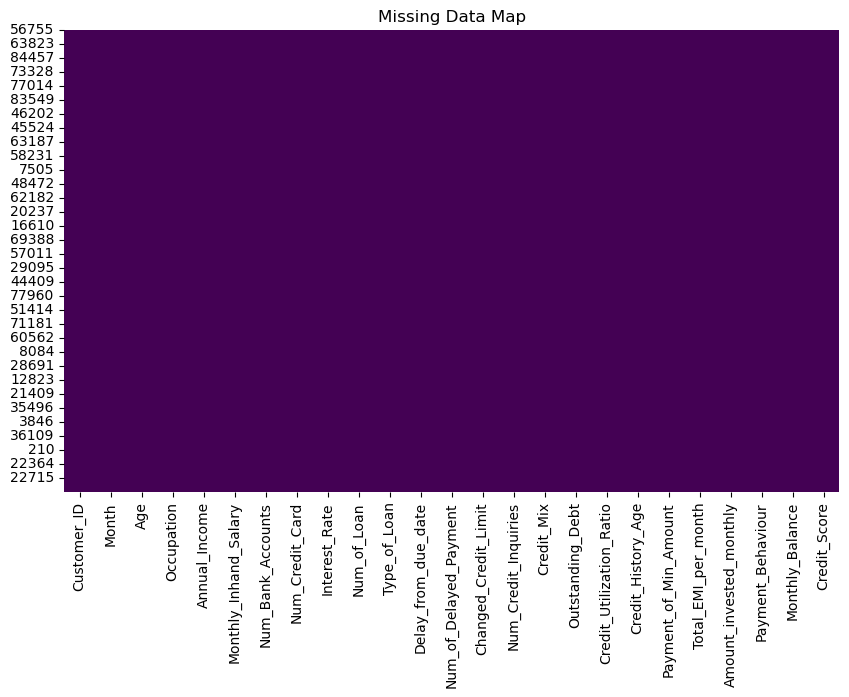

In [64]:
# Check missing values with heatmaps
plt.figure(figsize=(10,6))
sn.heatmap(train_df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Map")
plt.show()

### Nhóm Numerical

In [65]:
def outlier(col):
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR

    print("Q1 (25%):", Q1)
    print("Q3 (75%):", Q3)
    print("Upper limit:", upper_limit)
    print("Lower limit:", lower_limit)

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Age')

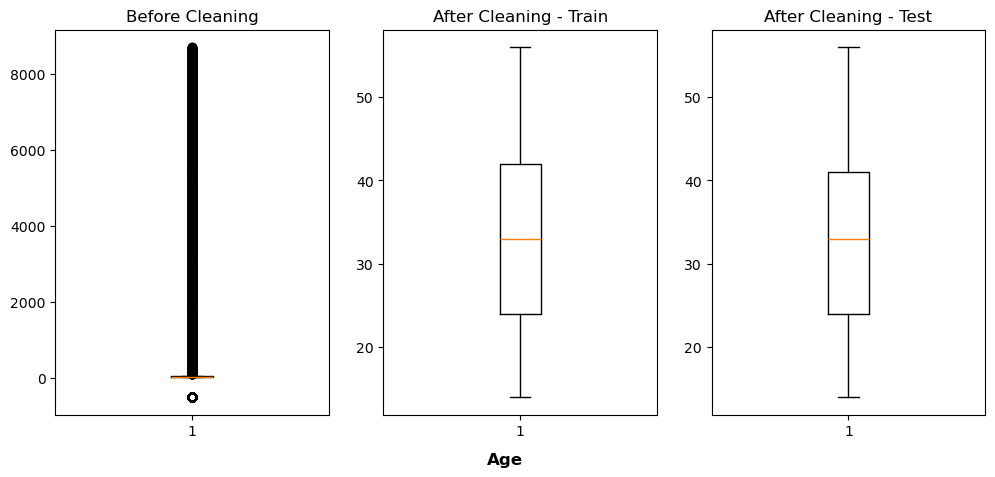

Min: 14.0
Max: 56.0
Q1 (25%): 24.0
Q3 (75%): 42.0
Upper limit: 69.0
Lower limit: -3.0


In [66]:
# Age
fig, axes = plt.subplots(1, 3, figsize=(12,5))
_ = axes[0].boxplot(x=df['Age'])
axes[0].set_title("Before Cleaning")

_ = axes[1].boxplot(x=train_df['Age'])
axes[1].set_title("After Cleaning - Train")

_ = axes[2].boxplot(x=test_df['Age'])
axes[2].set_title("After Cleaning - Test")


fig.text(0.5, 0.02, 'Age', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Age'].min())
print(f"Max:", train_df['Age'].max())
outlier('Age')

- Khách hàng nhỏ tuổi nhất: 14
- Khách hàng lớn tuổi nhất: 56
- Phổ biến nhất: 25-45

Most common Annual Income: 15k-25k

(5000.0, 160000.0)

Text(0.5, 1.0, 'Before Cleaning')

(5000.0, 160000.0)

Text(0.5, 1.0, 'After Cleaning - Train')

(5000.0, 160000.0)

...

Text(0.5, 1.0, 'After Cleaning - Train')

(0.0, 16000.0)

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.49, 'Annual_Income')

Text(0.5, 0.06, 'Monthly_Inhand_Salary')

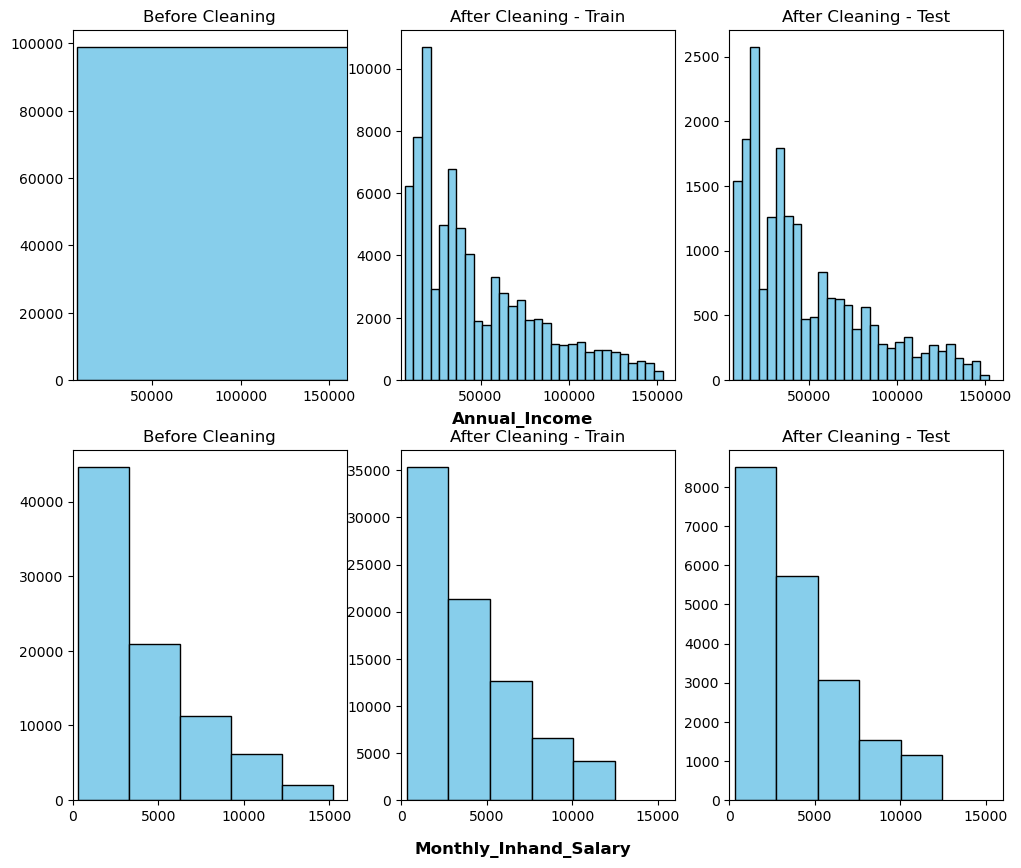

Annual_Income: 
Min: 7005.93
Max: 153147.64
Monthly_Inhand_Salary: 
Min: 319.55625
Max: 12495.47


In [67]:
# Annual_Income
fig, axes = plt.subplots(2, 3, figsize=(12,10))

_ = axes[0, 0].hist(df['Annual_Income'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlim(5000, 160000)
axes[0, 0].set_title("Before Cleaning")

_ = axes[0, 1].hist(train_df['Annual_Income'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_xlim(5000, 160000)
axes[0, 1].set_title("After Cleaning - Train")

_ = axes[0, 2].hist(test_df['Annual_Income'], bins=30, color='skyblue', edgecolor='black')
axes[0, 2].set_xlim(5000, 160000)
axes[0, 2].set_title("After Cleaning - Test")

# Monthly_Inhand_Salary
_ = axes[1, 0].hist(df['Monthly_Inhand_Salary'], bins=5, color='skyblue', edgecolor='black')
axes[1, 0].set_xlim(0, 16000)
axes[1, 0].set_title("Before Cleaning")

_ = axes[1, 1].hist(train_df['Monthly_Inhand_Salary'], bins=5, color='skyblue', edgecolor='black')
axes[1, 1].set_xlim(0, 16000)
axes[1, 1].set_title("After Cleaning - Train")

_ = axes[1, 2].hist(test_df['Monthly_Inhand_Salary'], bins=5, color='skyblue', edgecolor='black')
axes[1, 2].set_xlim(0, 16000)
axes[1, 2].set_title("After Cleaning - Test")

fig.text(0.5, 0.49, 'Annual_Income', ha='center', va='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.06, 'Monthly_Inhand_Salary', ha='center', va='center', fontsize=12, fontweight='bold')

plt.show()

print("Annual_Income: ")
print(f"Min:", train_df['Annual_Income'].min())
print(f"Max:", train_df['Annual_Income'].max())

print("Monthly_Inhand_Salary: ")
print(f"Min:", train_df['Monthly_Inhand_Salary'].min())
print(f"Max:", train_df['Monthly_Inhand_Salary'].max())


Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.49, 'Num_Bank_Accounts')

Text(0.5, 0.06, 'Num_Credit_Card')

Num_Bank_Accounts: 
Min: 0.0
Max: 11.0
Num_Credit_Card: 
Min: 0.0
Max: 11.0


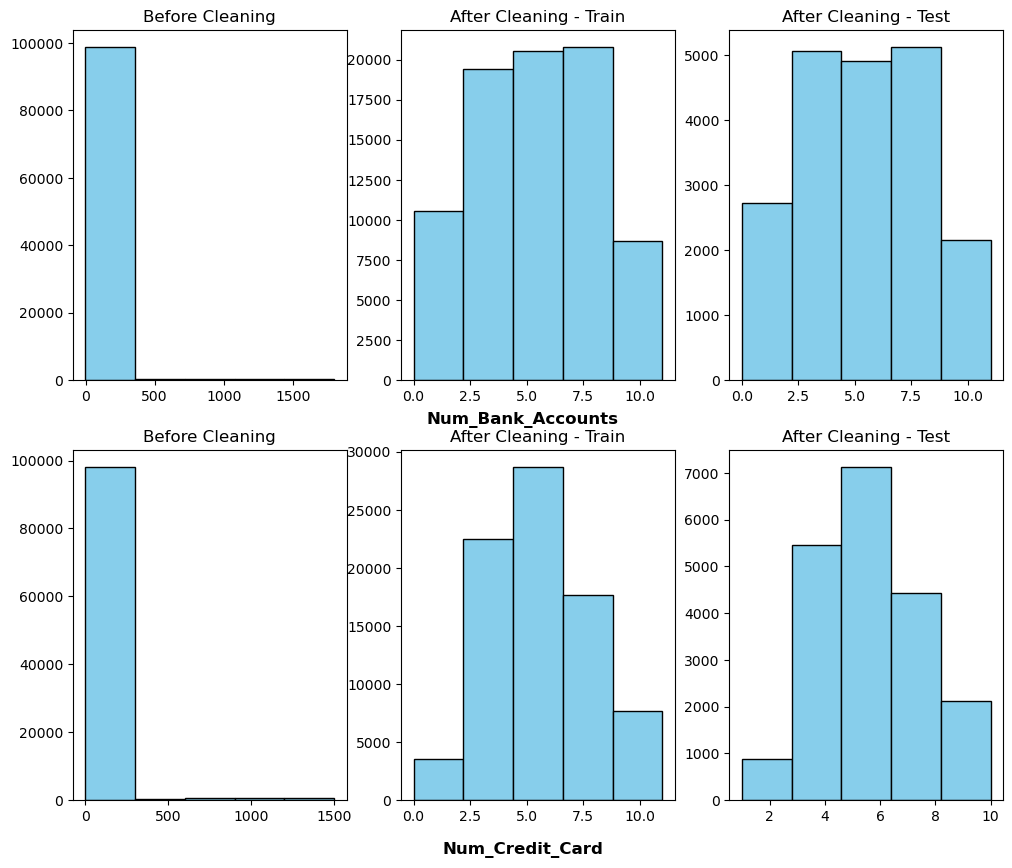

In [68]:
# Num_Bank_Accounts
fig, axes = plt.subplots(2, 3, figsize=(12,10))

_ = axes[0, 0].hist(df['Num_Bank_Accounts'], bins=5, color='skyblue', edgecolor='black')
axes[0 , 0].set_title("Before Cleaning")

_ = axes[0, 1].hist(train_df['Num_Bank_Accounts'], bins=5, color='skyblue', edgecolor='black')
axes[0, 1].set_title("After Cleaning - Train")

_ = axes[0, 2].hist(test_df['Num_Bank_Accounts'], bins=5, color='skyblue', edgecolor='black')
axes[0, 2].set_title("After Cleaning - Test")

# Num_Credit_Card
_ = axes[1, 0].hist(df['Num_Credit_Card'], bins=5, color='skyblue', edgecolor='black')
axes[1, 0].set_title("Before Cleaning")

_ = axes[1, 1].hist(train_df['Num_Credit_Card'], bins=5, color='skyblue', edgecolor='black')
axes[1, 1].set_title("After Cleaning - Train")

_ = axes[1, 2].hist(test_df['Num_Credit_Card'], bins=5, color='skyblue', edgecolor='black')
axes[1, 2].set_title("After Cleaning - Test")

fig.text(0.5, 0.49, 'Num_Bank_Accounts', ha='center', va='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.06, 'Num_Credit_Card', ha='center', va='center', fontsize=12, fontweight='bold')

print("Num_Bank_Accounts: ")
print(f"Min:", train_df['Num_Bank_Accounts'].min()) # Có giá trị âm
print(f"Max:", train_df['Num_Bank_Accounts'].max())

print("Num_Credit_Card: ")
print(f"Min:", train_df['Num_Credit_Card'].min())
print(f"Max:", train_df['Num_Credit_Card'].max())



Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Interest_Rate')

Min: 1.0
Max: 34.0


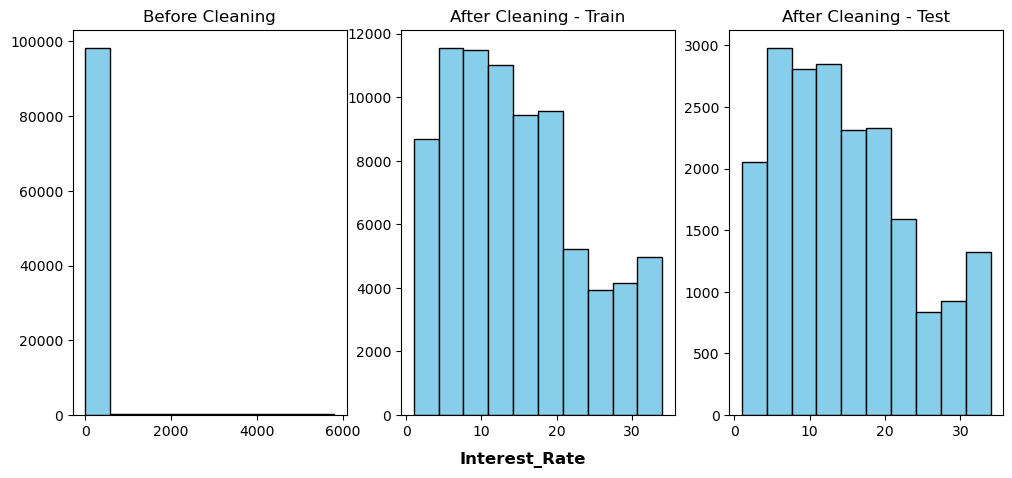

In [69]:
# Interest_Rate
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Interest_Rate'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Interest_Rate'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Interest_Rate'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Interest_Rate', ha='center', va='center', fontsize=12, fontweight='bold')

print(f"Min:", train_df['Interest_Rate'].min())
print(f"Max:", train_df['Interest_Rate'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Num_of_Loan')

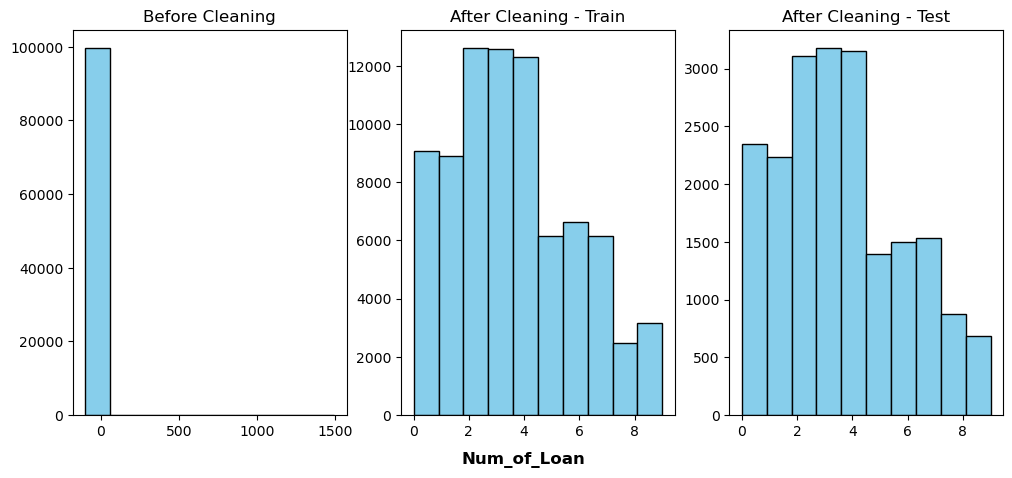

Min: 0.0
Max: 9.0


In [70]:
# Num_of_Loan
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Num_of_Loan'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Num_of_Loan'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Num_of_Loan'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Num_of_Loan', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Num_of_Loan'].min()) # Có số âm
print(f"Max:", train_df['Num_of_Loan'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.49, 'Delay_from_due_date')

Text(0.5, 0.06, 'Num_of_Delayed_Payment')

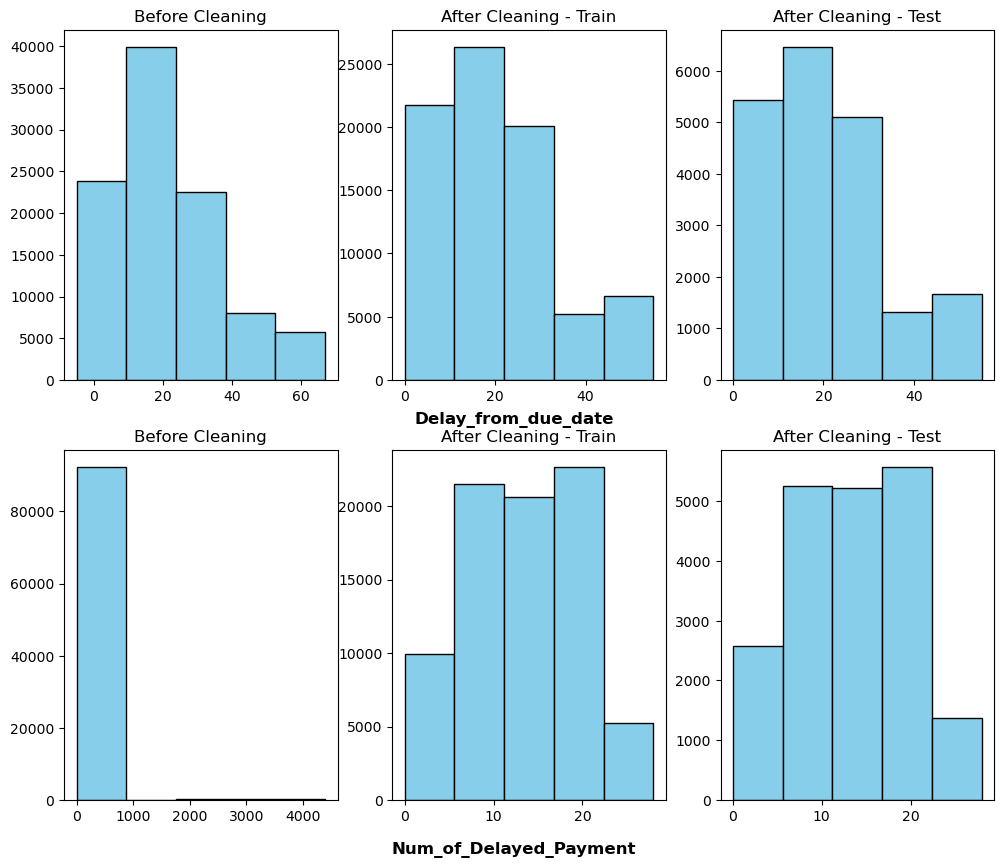

Delay_from_due_date: 
Min: 0.0
Max: 55.0
Num_of_Delayed_Payment: 
Min: 0.0
Max: 28.0


In [71]:
# Delay_from_due_date
fig, axes = plt.subplots(2, 3, figsize=(12,10))

_ = axes[0, 0].hist(df['Delay_from_due_date'], bins=5, color='skyblue', edgecolor='black')
axes[0 , 0].set_title("Before Cleaning")

_ = axes[0, 1].hist(train_df['Delay_from_due_date'], bins=5, color='skyblue', edgecolor='black')
axes[0, 1].set_title("After Cleaning - Train")

_ = axes[0, 2].hist(test_df['Delay_from_due_date'], bins=5, color='skyblue', edgecolor='black')
axes[0, 2].set_title("After Cleaning - Test")

# Num_of_Delayed_Payment
_ = axes[1, 0].hist(df['Num_of_Delayed_Payment'], bins=5, color='skyblue', edgecolor='black')
axes[1, 0].set_title("Before Cleaning")

_ = axes[1, 1].hist(train_df['Num_of_Delayed_Payment'], bins=5, color='skyblue', edgecolor='black')
axes[1, 1].set_title("After Cleaning - Train")

_ = axes[1, 2].hist(test_df['Num_of_Delayed_Payment'], bins=5, color='skyblue', edgecolor='black')
axes[1, 2].set_title("After Cleaning - Test")

fig.text(0.5, 0.49, 'Delay_from_due_date', ha='center', va='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.06, 'Num_of_Delayed_Payment', ha='center', va='center', fontsize=12, fontweight='bold')

plt.show()

print("Delay_from_due_date: ")
print(f"Min:", train_df['Delay_from_due_date'].min()) # có số âm
print(f"Max:", train_df['Delay_from_due_date'].max())

print("Num_of_Delayed_Payment: ")
print(f"Min:", train_df['Num_of_Delayed_Payment'].min()) # Có số âm
print(f"Max:", train_df['Num_of_Delayed_Payment'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Changed_Credit_Limit')

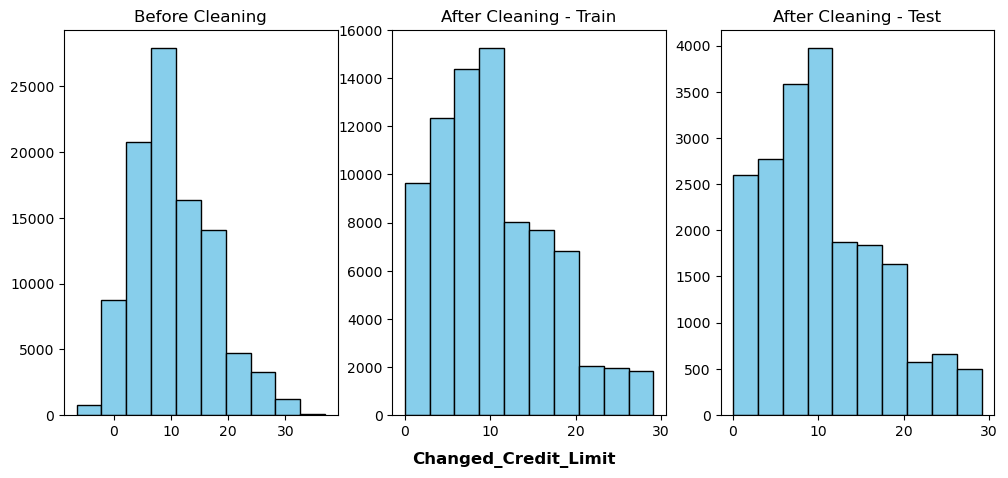

Min: 0.0
Max: 29.12


In [72]:
# Changed_Credit_Limit
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Changed_Credit_Limit'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Changed_Credit_Limit'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Changed_Credit_Limit'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Changed_Credit_Limit', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Changed_Credit_Limit'].min()) # Có số âm
print(f"Max:", train_df['Changed_Credit_Limit'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Num_Credit_Inquiries')

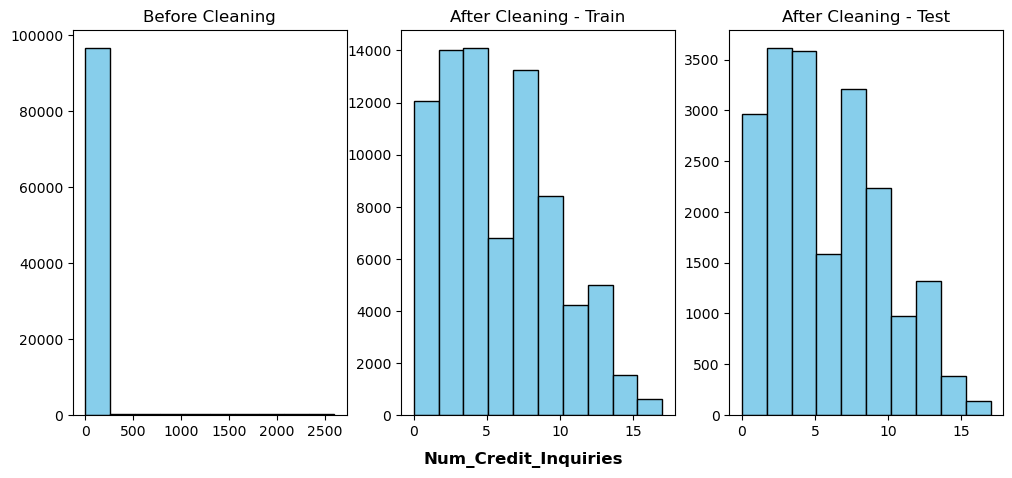

Min: 0.0
Max: 17.0


In [73]:
# Num_Credit_Inquiries
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Num_Credit_Inquiries'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Num_Credit_Inquiries'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Num_Credit_Inquiries'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Num_Credit_Inquiries', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Num_Credit_Inquiries'].min())
print(f"Max:", train_df['Num_Credit_Inquiries'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Outstanding_Debt')

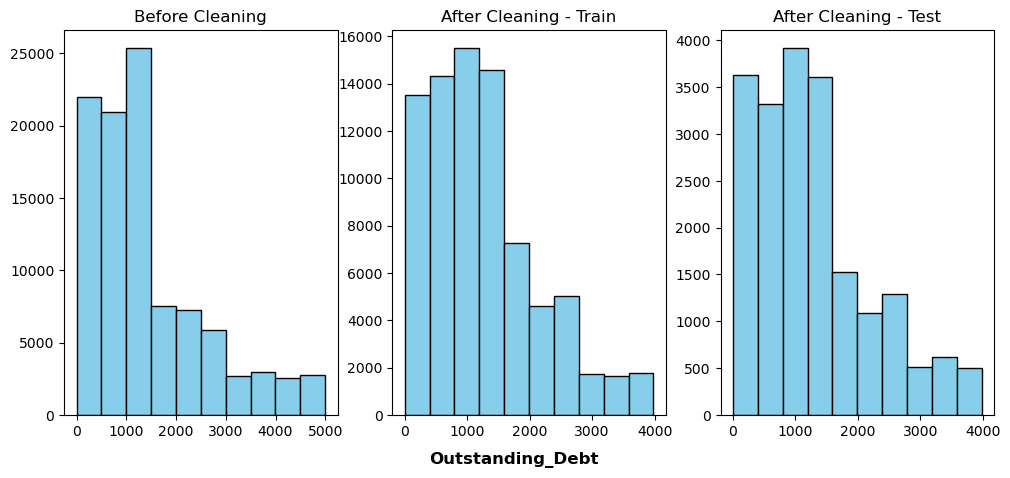

Min: 0.34
Max: 3980.41


In [74]:
# Outstanding_Debt
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Outstanding_Debt'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Outstanding_Debt'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Outstanding_Debt'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Outstanding_Debt', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Outstanding_Debt'].min())
print(f"Max:", train_df['Outstanding_Debt'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Credit_Utilization_Ratio')

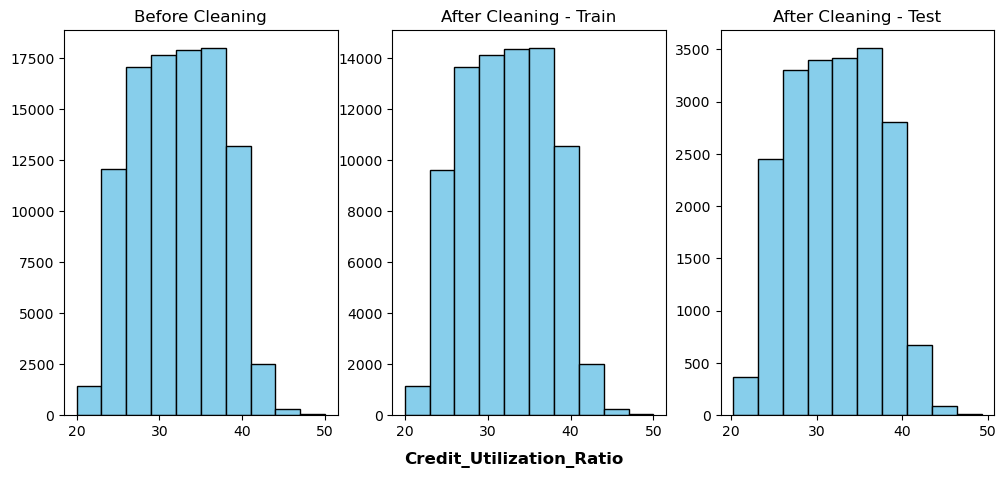

Min: 20.0
Max: 50.00000000000001


In [75]:
# Credit_Utilization_Ratio
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Credit_Utilization_Ratio'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Credit_Utilization_Ratio'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Credit_Utilization_Ratio'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Credit_Utilization_Ratio', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Credit_Utilization_Ratio'].min())
print(f"Max:", train_df['Credit_Utilization_Ratio'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.02, 'Total_EMI_per_month')

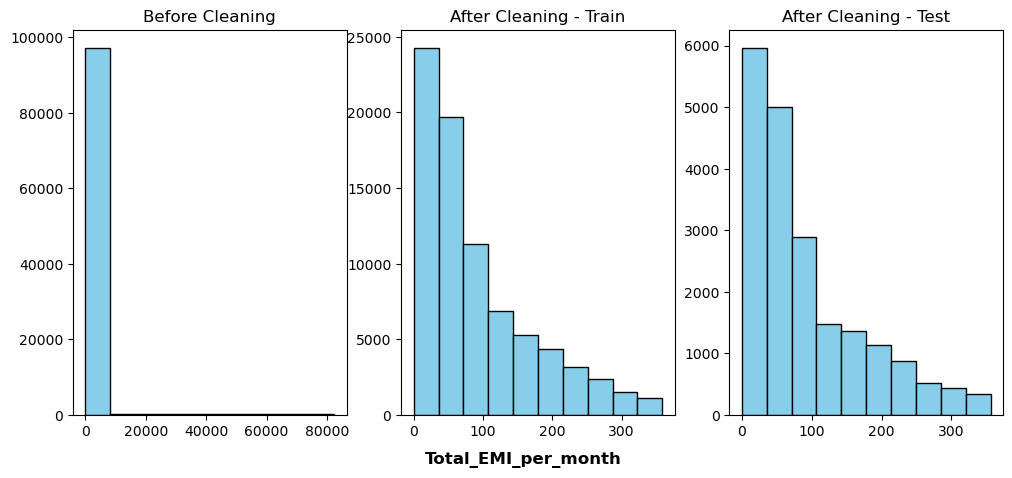

Min: 0.0
Max: 358.8601965712291


In [76]:
# Total_EMI_per_month
fig, axes = plt.subplots(1, 3, figsize=(12,5))

_ = axes[0].hist(df['Total_EMI_per_month'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(train_df['Total_EMI_per_month'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(test_df['Total_EMI_per_month'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

fig.text(0.5, 0.02, 'Total_EMI_per_month', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Min:", train_df['Total_EMI_per_month'].min())
print(f"Max:", train_df['Total_EMI_per_month'].max())

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

Text(0.5, 0.49, 'Amount_invested_monthly')

Text(0.5, 0.06, 'Monthly_Balance')

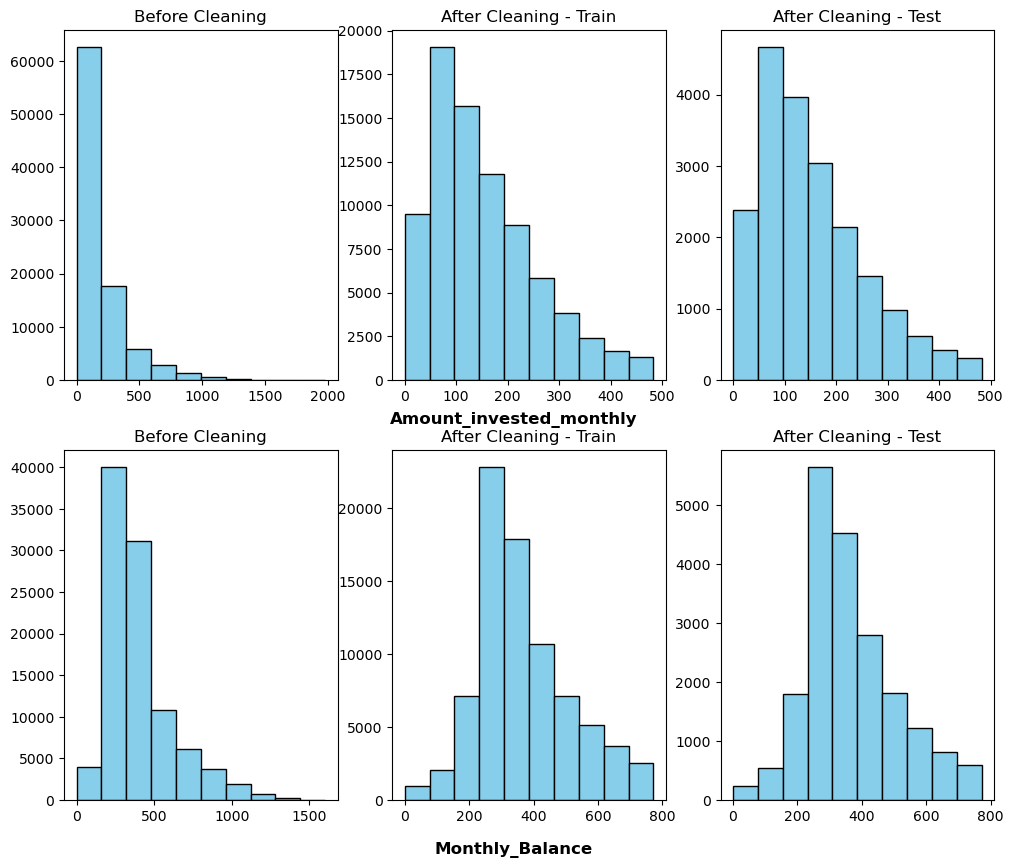

Amount_invested_monthly: 
Min: 0.0
Max: 483.0822931704178
Monthly_Balance: 
Min: 0.0077596647753352
Max: 772.0716778014428


In [77]:
# Amount_invested_monthly
fig, axes = plt.subplots(2, 3, figsize=(12,10))

_ = axes[0, 0].hist(df['Amount_invested_monthly'], bins=10, color='skyblue', edgecolor='black')
axes[0 , 0].set_title("Before Cleaning")

_ = axes[0, 1].hist(train_df['Amount_invested_monthly'], bins=10, color='skyblue', edgecolor='black')
axes[0, 1].set_title("After Cleaning - Train")

_ = axes[0, 2].hist(test_df['Amount_invested_monthly'], bins=10, color='skyblue', edgecolor='black')
axes[0, 2].set_title("After Cleaning - Test")

# Monthly_Balance
_ = axes[1, 0].hist(df['Monthly_Balance'], bins=10, color='skyblue', edgecolor='black')
axes[1, 0].set_title("Before Cleaning")

_ = axes[1, 1].hist(train_df['Monthly_Balance'], bins=10, color='skyblue', edgecolor='black')
axes[1, 1].set_title("After Cleaning - Train")

_ = axes[1, 2].hist(test_df['Monthly_Balance'], bins=10, color='skyblue', edgecolor='black')
axes[1, 2].set_title("After Cleaning - Test")

fig.text(0.5, 0.49, 'Amount_invested_monthly', ha='center', va='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.06, 'Monthly_Balance', ha='center', va='center', fontsize=12, fontweight='bold')
plt.show()

print("Amount_invested_monthly: ")
print(f"Min:", train_df['Amount_invested_monthly'].min())
print(f"Max:", train_df['Amount_invested_monthly'].max())

print("Monthly_Balance: ")
print(f"Min:", train_df['Monthly_Balance'].min())
print(f"Max:", train_df['Monthly_Balance'].max())

### Nhóm Categorical

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

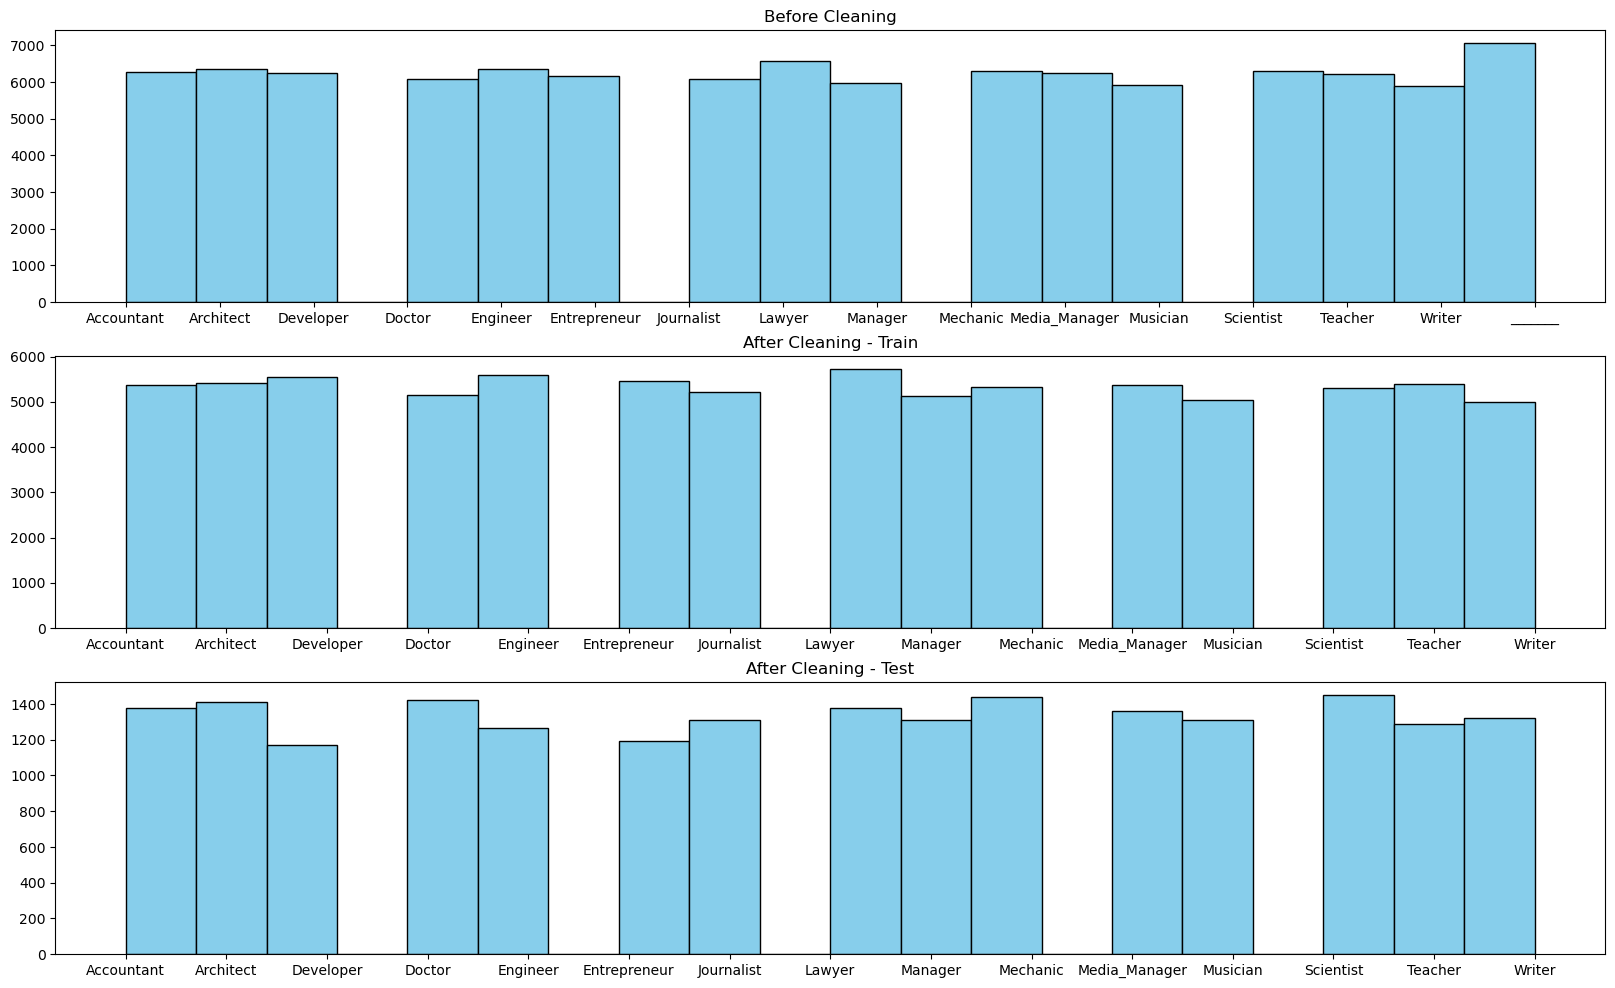

In [78]:
# Occupation

fig, axes = plt.subplots(3, 1, figsize=(20,12))

sorted_df = df.sort_values(by='Occupation')
sorted_train = train_df.sort_values(by='Occupation')
sorted_test = test_df.sort_values(by='Occupation')

_ = axes[0].hist(x=sorted_df['Occupation'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(x=sorted_train['Occupation'], bins=20, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(x=sorted_test['Occupation'], bins=20, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

# There is value "____"

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

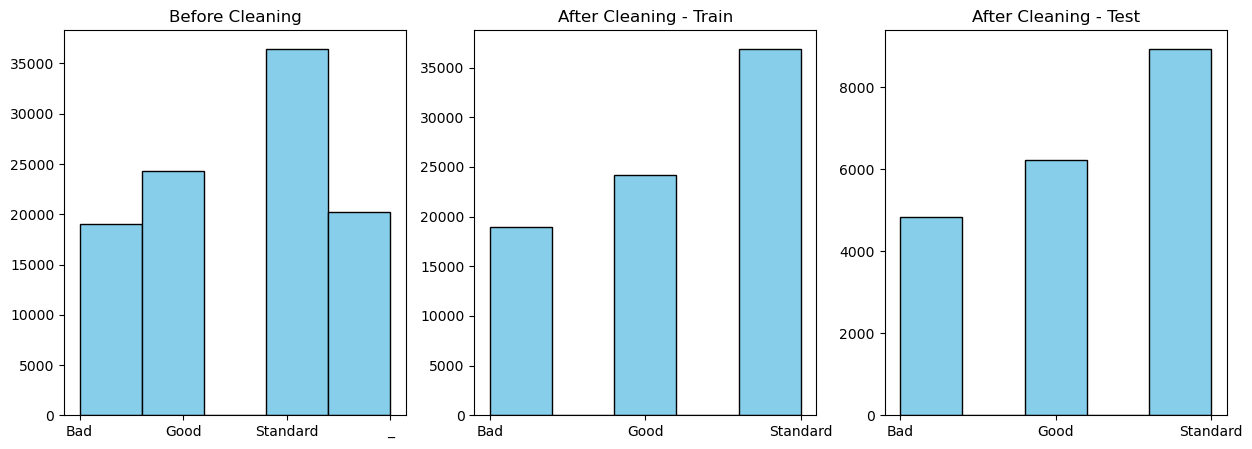

In [79]:
# Credit_Mix
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sorted_df = df.sort_values(by='Credit_Mix')
sorted_train = train_df.sort_values(by='Credit_Mix')
sorted_test = test_df.sort_values(by='Credit_Mix')

_ = axes[0].hist(x=sorted_df['Credit_Mix'], bins=5, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(x=sorted_train['Credit_Mix'], bins=5, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(x=sorted_test['Credit_Mix'], bins=5, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

# There is value "____"

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

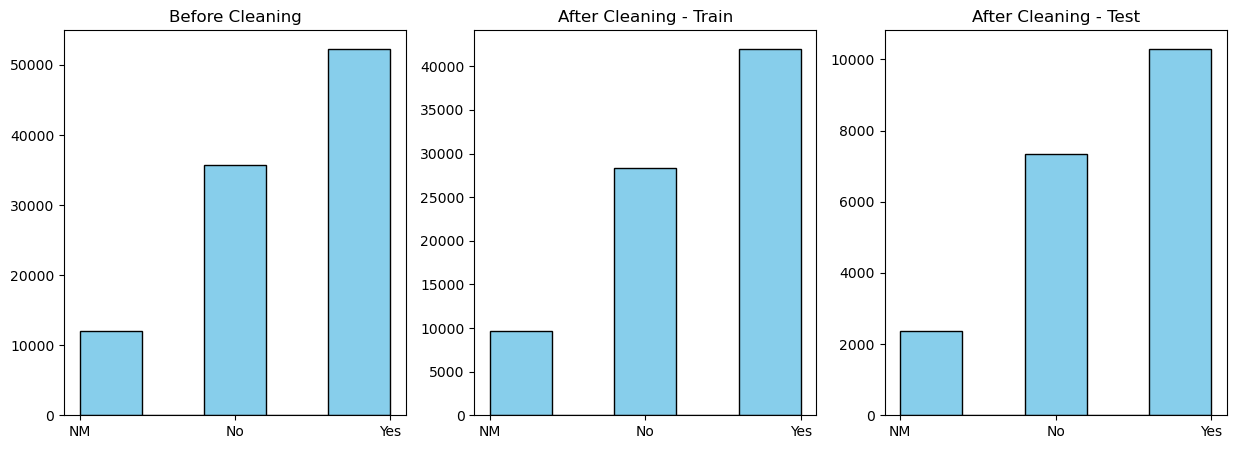

In [80]:
# Payment_of_Min_Amount
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sorted_df = df.sort_values(by='Payment_of_Min_Amount')
sorted_train = train_df.sort_values(by='Payment_of_Min_Amount')
sorted_test = test_df.sort_values(by='Payment_of_Min_Amount')

_ = axes[0].hist(x=sorted_df['Payment_of_Min_Amount'], bins=5, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(x=sorted_train['Payment_of_Min_Amount'], bins=5, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(x=sorted_test['Payment_of_Min_Amount'], bins=5, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

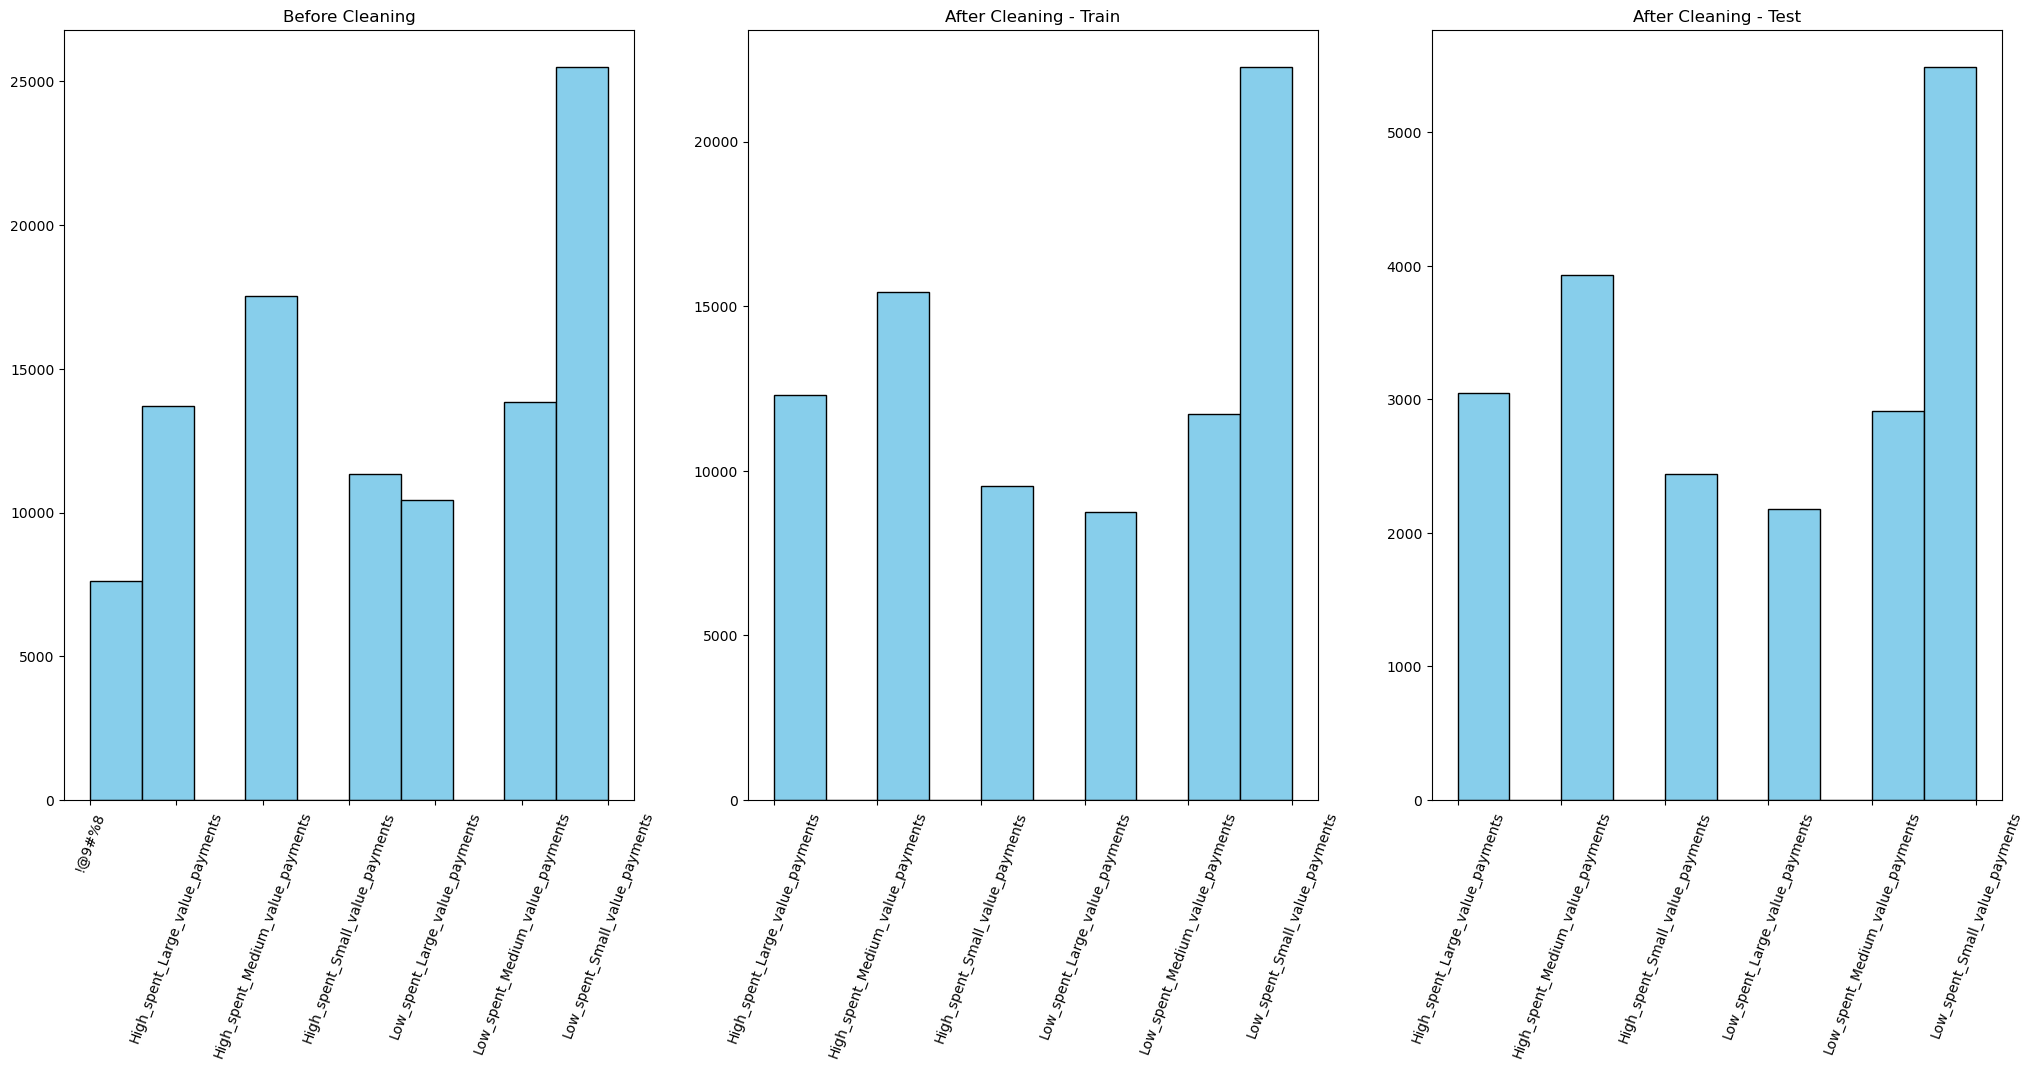

In [81]:
# Payment_Behaviour
fig, axes = plt.subplots(1, 3, figsize=(25,10))

sorted_df = df.sort_values(by='Payment_Behaviour')
sorted_train = train_df.sort_values(by='Payment_Behaviour')
sorted_test = test_df.sort_values(by='Payment_Behaviour')

_ = axes[0].hist(x=sorted_df['Payment_Behaviour'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")
axes[0].tick_params(axis='x', rotation=70)


_ = axes[1].hist(x=sorted_train['Payment_Behaviour'], bins=10, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")
axes[1].tick_params(axis='x', rotation=70)

_ = axes[2].hist(x=sorted_test['Payment_Behaviour'], bins=10, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")
axes[2].tick_params(axis='x', rotation=70)

# There are outliners

Text(0.5, 1.0, 'Before Cleaning')

Text(0.5, 1.0, 'After Cleaning - Train')

Text(0.5, 1.0, 'After Cleaning - Test')

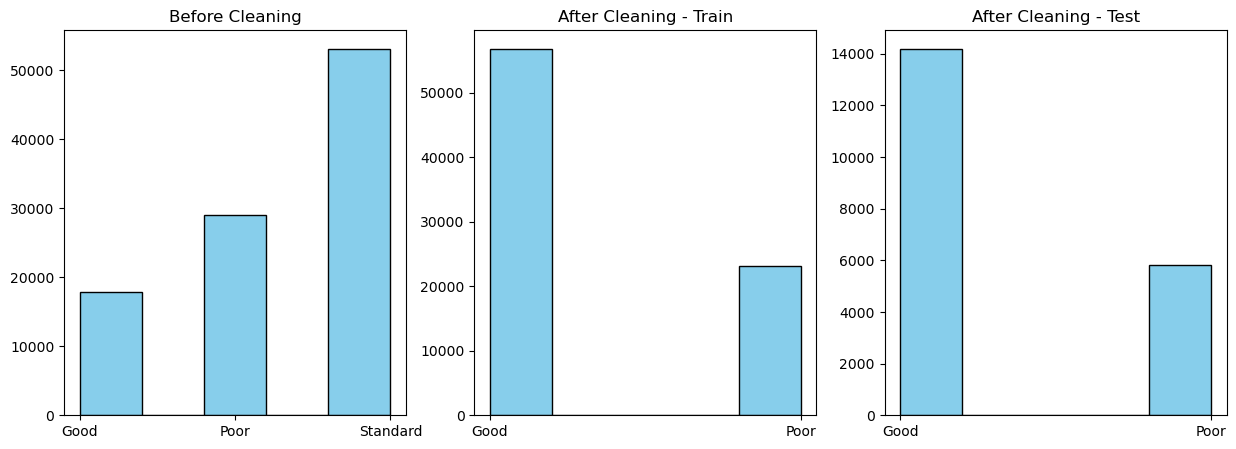

In [82]:
# Credit_Score - Target
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sorted_df = df.sort_values(by='Credit_Score')
sorted_train = train_df.sort_values(by='Credit_Score')
sorted_test = test_df.sort_values(by='Credit_Score')

_ = axes[0].hist(x=sorted_df['Credit_Score'], bins=5, color='skyblue', edgecolor='black')
axes[0].set_title("Before Cleaning")

_ = axes[1].hist(x=sorted_train['Credit_Score'], bins=5, color='skyblue', edgecolor='black')
axes[1].set_title("After Cleaning - Train")

_ = axes[2].hist(x=sorted_test['Credit_Score'], bins=5, color='skyblue', edgecolor='black')
axes[2].set_title("After Cleaning - Test")
# There are outliners
# Imbalanced

### Correlation with Credit_Score

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Delay_from_due_date', ylabel='Annual_Income'>

Text(0.5, 1.0, 'Delay_from_due_date vs Annual_Income by Credit Score')

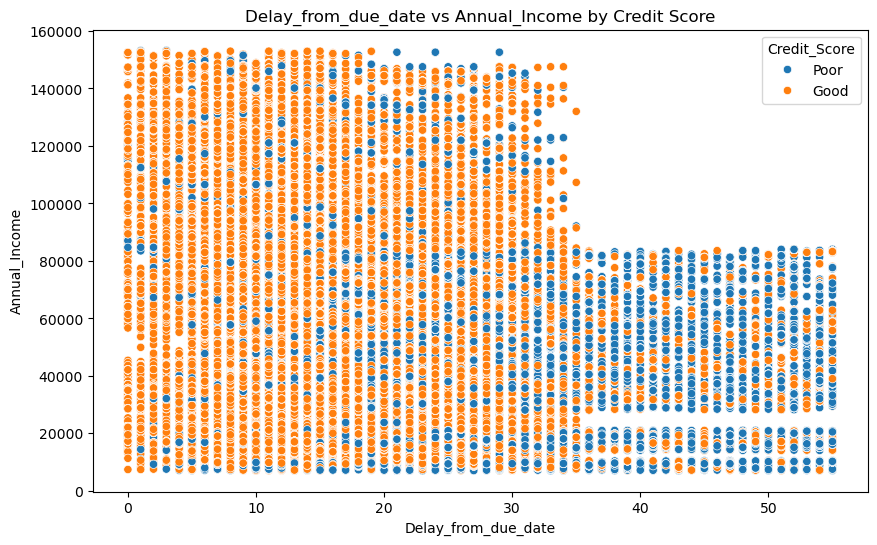

In [83]:
# Delay_from_due_date vs Annual_Income by Credit Score
plt.figure(figsize=(10,6))
sn.scatterplot(x="Delay_from_due_date", y="Annual_Income", hue="Credit_Score", data=train_df)
plt.title("Delay_from_due_date vs Annual_Income by Credit Score")

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Delay_from_due_date', ylabel='Num_of_Delayed_Payment'>

Text(0.5, 1.0, 'Delay_from_due_date vs Num_of_Delayed_Payment by Credit Score')

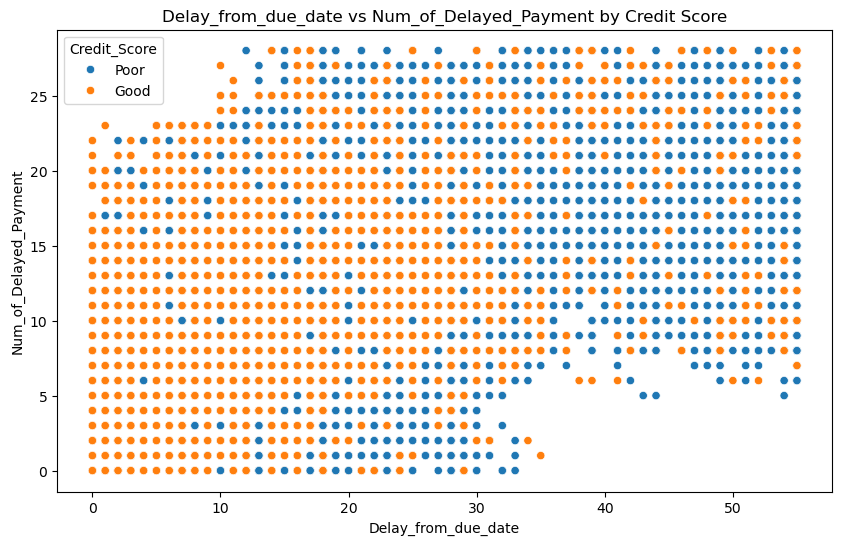

In [84]:
# Delay_from_due_date vs Num_of_Delayed_Payment by Credit Score
plt.figure(figsize=(10,6))
sn.scatterplot(x="Delay_from_due_date", y="Num_of_Delayed_Payment", hue="Credit_Score", data=train_df)
plt.title("Delay_from_due_date vs Num_of_Delayed_Payment by Credit Score")

- Thường những người có thu nhập hằng năm thấp dưới 80k/năm có tỉ lệ delay nợ nhiều hơn

In [85]:
train_df.groupby("Credit_Score")[["Delay_from_due_date", "Num_of_Delayed_Payment", "Annual_Income"]].mean()

,Delay_from_due_date,Num_of_Delayed_Payment,Annual_Income
Credit_Score,,,
Good,16.963260,12.282234,51896.198868
Poor,27.574797,15.906018,39338.862535


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Monthly_Inhand_Salary', ylabel='Annual_Income'>

Text(0.5, 1.0, 'Monthly_Inhand_Salary vs Annual_Income by Credit Score')

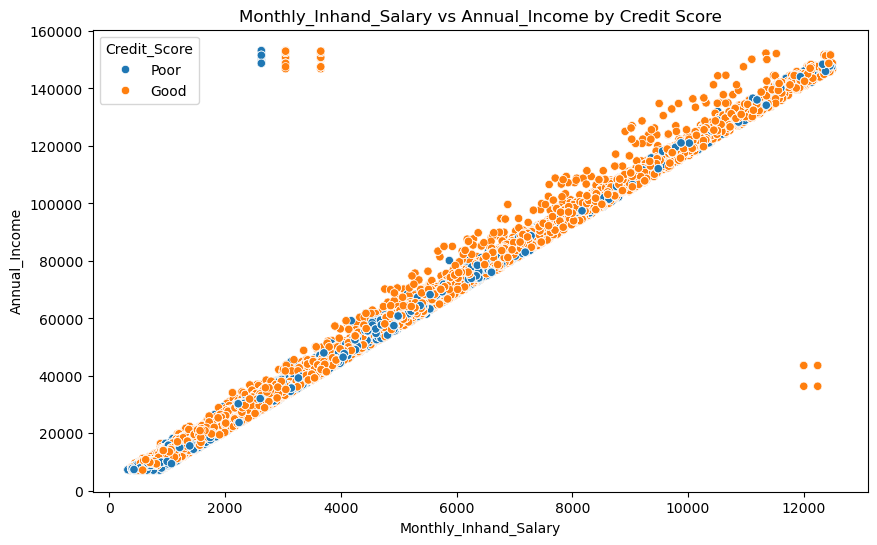

In [86]:
# Monthly_Inhand_Salary vs Annual_Income by Credit Score
plt.figure(figsize=(10,6))
sn.scatterplot(x="Monthly_Inhand_Salary", y="Annual_Income", hue="Credit_Score", data=train_df)
plt.title("Monthly_Inhand_Salary vs Annual_Income by Credit Score")

- Monthly_Inhand_Salary increases = Annual_Income increases

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Num_of_Delayed_Payment', ylabel='Outstanding_Debt'>

Text(0.5, 1.0, 'Delay_from_due_date vs Annual_Income by Credit Score')

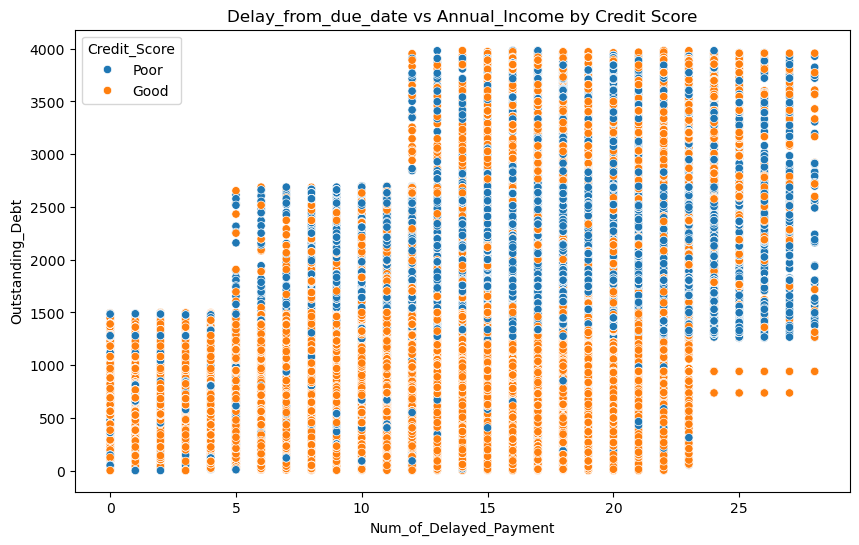

In [87]:
# Num_of_Delayed_Payment vs Outstanding_Debt by Credit Score
plt.figure(figsize=(10,6))
sn.scatterplot(x="Num_of_Delayed_Payment", y="Outstanding_Debt", hue="Credit_Score", data=train_df)
plt.title("Delay_from_due_date vs Annual_Income by Credit Score")

In [88]:
train_df.groupby("Credit_Score")[["Delay_from_due_date", "Num_of_Delayed_Payment", "Annual_Income"]].mean()

,Delay_from_due_date,Num_of_Delayed_Payment,Annual_Income
Credit_Score,,,
Good,16.963260,12.282234,51896.198868
Poor,27.574797,15.906018,39338.862535


Các nhóm features có liên hệ với nhau:
- Annual_Income và Monthly_Inhand_Salary
- Num_of_Delayed_Payment, Num_Credit_Inquiries, Outstanding_Debt, Num_Credit_Card
- Monthly_Balance, Monthly_Inhand_Salary, Annual_Income
- Total_EMI_per_month và Monthly_Inhand_Salary

# -- NOTES --

- Các outlier đã được xử lý
- Do số lượng các features nhiều cùng với việc các vấn đề tương tự nhau missing values, outliers -> xử dụng function để xử lý theo nhóm

- Annual_Income giảm range từ 7k-2400k đến 7k-150k
- Cột Age có tăng độ tuổi

Các vấn đề mới tìm được:
- Imbalance của feature target (Credit_Score) -> cần sampling
- Khá nhiều feature imbalance
- Đa phần feature dạng categorical có thể encode
- Trường hợp số liệu có thể imbalance vì quá sạch?

Imbalance:
- Monthly_Inhand_Salary
- Num_Bank_Accounts
- Num_Credit_Card
- Interest_Rate
- Outstanding_Debt

Special (maybe imbalance):
- Total_EMI_per_month
- Amount_invested_monthly

Cần encode:
- Credit_Score
- Payment_Behaviour
- Payment_of_Min_Amount
- Credit_Mix
- Occupation